In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

# Create outputs/plots if it doesn't exist
os.makedirs(os.path.join('..', 'outputs', 'plots'), exist_ok=True)


In [2]:
# Load data/raw/steam_reviews.csv
data_path = os.path.join('..', 'data', 'raw', 'steam_reviews.csv')
print(f"Loading data from {data_path}")
df = pd.read_csv(data_path)

if len(df) > 100000:
    df = df.sample(n=100000, random_state=42)
    print('Sampled down to 100000 rows')


Loading data from ..\data\raw\steam_reviews.csv


Sampled down to 100000 rows


In [3]:
# Show shape, dtypes, null counts, duplicate count
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nNull Counts:\n", df.isnull().sum())
print("\nDuplicate Count:", df.duplicated().sum())


Shape: (100000, 5)

Dtypes:
 app_id          int64
app_name          str
review_text       str
review_score    int64
review_votes    int64
dtype: object

Null Counts:
 app_id             0
app_name        2883
review_text      111
review_score       0
review_votes       0
dtype: int64

Duplicate Count: 14576


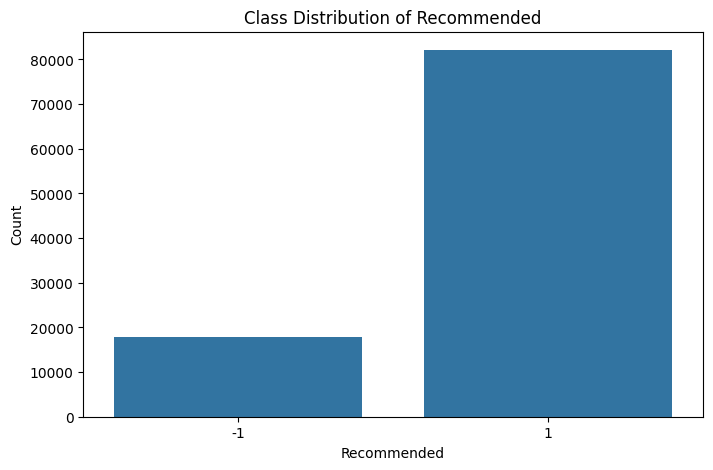

In [4]:
# Function to save plots
def save_plot(filename):
    plt.savefig(os.path.join('..', 'outputs', 'plots', filename), bbox_inches='tight')
    plt.show()

# Plot 1: Bar chart — class distribution of recommended
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='review_score')
plt.title('Class Distribution of Recommended')
plt.xlabel('Recommended')
plt.ylabel('Count')
save_plot('01_class_distribution.png')


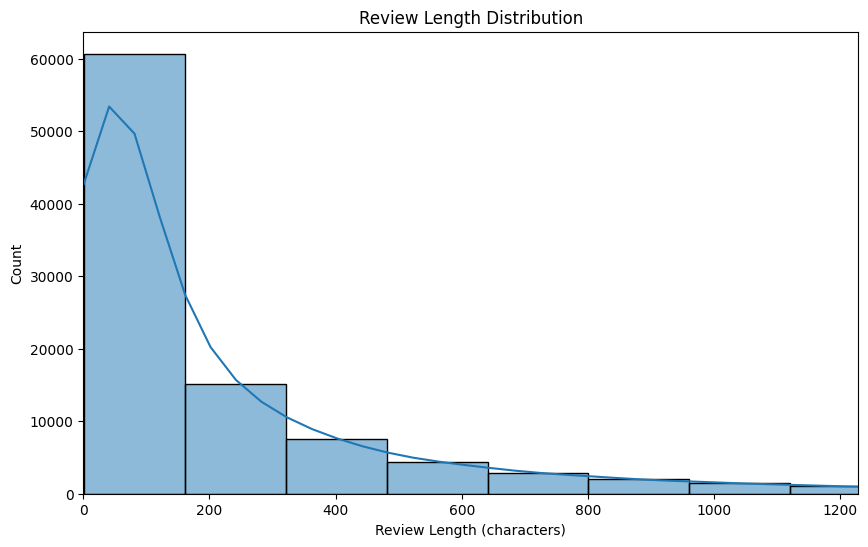

In [5]:
# Plot 2: Histogram — review length distribution
df['review_length'] = df['review_text'].astype(str).str.len()
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Review Length Distribution')
plt.xlabel('Review Length (characters)')
plt.ylabel('Count')
plt.xlim(0, df['review_length'].quantile(0.95))
save_plot('02_review_length_distribution.png')


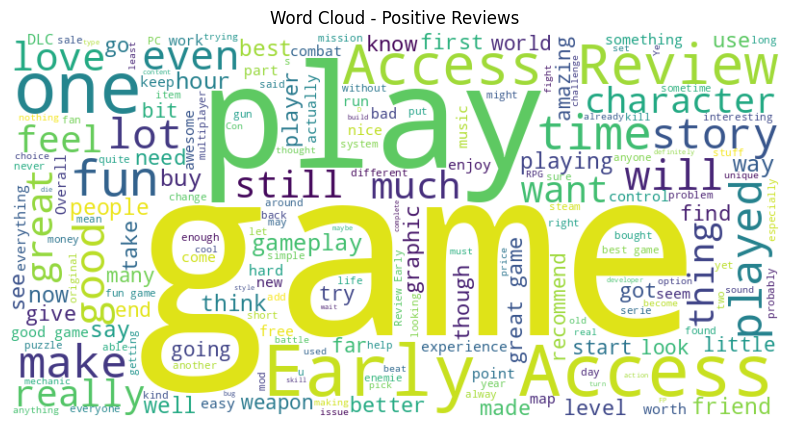

In [6]:
# Plot 3: Word cloud — positive reviews (recommended=True)
positive_reviews = ' '.join(df[df['review_score'] == 1]['review_text'].dropna().astype(str).tolist())
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Positive Reviews')
save_plot('03_wordcloud_positive.png')


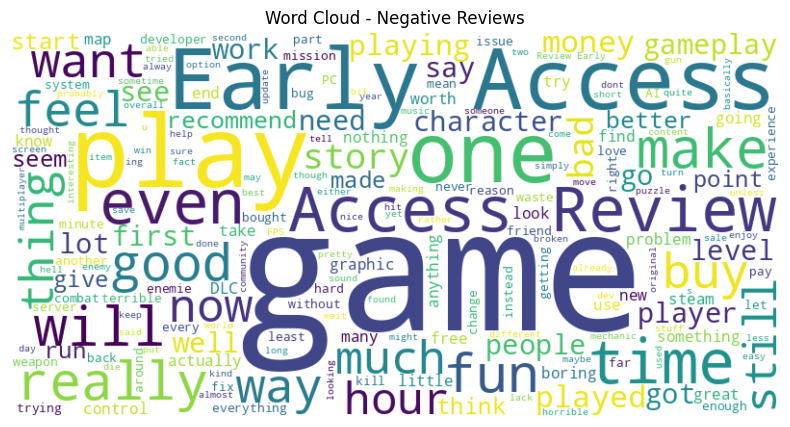

In [7]:
# Plot 4: Word cloud — negative reviews (recommended=False)
negative_reviews = ' '.join(df[df['review_score'] == -1]['review_text'].dropna().astype(str).tolist())
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Negative Reviews')
save_plot('04_wordcloud_negative.png')


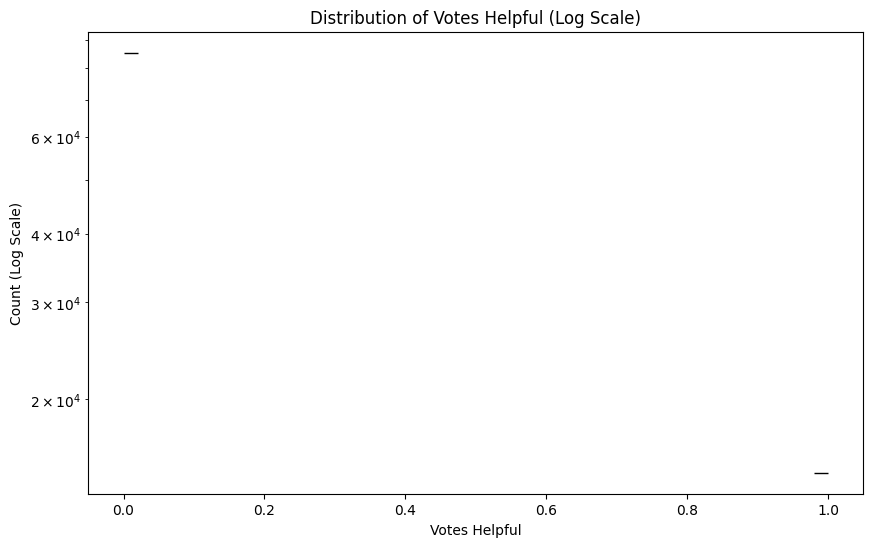

In [8]:
# Plot 5: Distribution of votes_helpful (log scale)
plt.figure(figsize=(10, 6))
sns.histplot(df['review_votes'], bins=50, log_scale=(False, True))
plt.title('Distribution of Votes Helpful (Log Scale)')
plt.xlabel('Votes Helpful')
plt.ylabel('Count (Log Scale)')
save_plot('05_votes_helpful_distribution.png')


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_19092\2583085460.py:13: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(0, df['playtime_hours'].quantile(0.95))


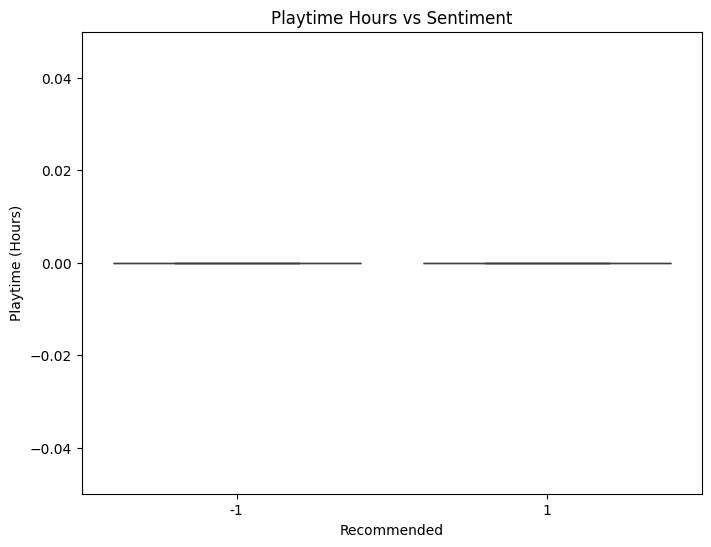

In [9]:
# Plot 6: Box plot — playtime_hours vs sentiment
if 'author.playtime_forever' in df.columns:
    df['playtime_hours'] = df['author.playtime_forever'] / 60.0
else:
    df['playtime_hours'] = 0

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='review_score', y='playtime_hours')
plt.title('Playtime Hours vs Sentiment')
plt.xlabel('Recommended')
plt.ylabel('Playtime (Hours)')
try:
    plt.ylim(0, df['playtime_hours'].quantile(0.95))
except:
    pass
save_plot('06_playtime_vs_sentiment.png')


In [10]:
# Plot 7: Line chart — review count over time (monthly)
if 'timestamp_created' in df.columns:
    df['created_date'] = pd.to_datetime(df['timestamp_created'], unit='s')
    # Using 'ME' for month end or 'M'
    monthly_counts = df.set_index('created_date').resample('ME').size()
    
    plt.figure(figsize=(12, 6))
    monthly_counts.plot(kind='line')
    plt.title('Review Count Over Time (Monthly)')
    plt.xlabel('Date')
    plt.ylabel('Number of Reviews')
    save_plot('07_review_count_over_time.png')
